In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
df = pd.read_excel(r"C:\for_chenna\5th sem\chenna_analytics_project\aldehyde_prj_dataset.xlsx")
df.head()

,Case,Temperature (K),Pressure (Pa),Volume (m3),Feed CH3CHO (mol/s),Product CH3CHO (mol/s),Conversion (%),Heat Load (kW),Residence Time (s),Status,Unnamed: 10,Automation Summary,Unnamed: 12
0,1,940.0,31330,0.90,22.700156,10.326473,54.509244,-244.848493,0.158951,OK,NaN,Total Cases,3000
1,2,940.0,31330,0.92,22.700156,10.177989,55.163355,-247.787257,0.162483,OK,NaN,Temperature Range,940.0 - 960.0 K
2,3,940.0,31330,0.94,22.700156,9.776531,56.931877,-255.732851,0.166015,OK,NaN,Pressure Range,31330.0 - 33330.0 Pa
3,4,940.0,31330,0.96,22.700156,9.632227,57.567576,-258.588926,0.169548,OK,NaN,Volume Range,0.90000000000000002 - 1.1000000000000001 m3
4,5,940.0,31330,0.98,22.700156,9.226590,59.354510,-266.617326,0.173080,OK,NaN,Message,3000-case automation completed


Dataset Validation and Cleaning


In [3]:
df.drop(columns=['Unnamed: 10','Automation Summary','Unnamed: 12'],inplace=True)
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
df.fillna(df.mean(numeric_only=True),inplace=True)
print(df.info())


Rows    : 3000
Columns : 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Case                    3000 non-null   int64  
 1   Temperature (K)         3000 non-null   float64
 2   Pressure (Pa)           3000 non-null   int64  
 3   Volume (m3)             3000 non-null   float64
 4   Feed CH3CHO (mol/s)     3000 non-null   float64
 5   Product CH3CHO (mol/s)  3000 non-null   float64
 6   Conversion (%)          3000 non-null   float64
 7   Heat Load (kW)          3000 non-null   float64
 8   Residence Time (s)      3000 non-null   float64
 9   Status                  3000 non-null   object 
dtypes: float64(7), int64(2), object(1)
memory usage: 234.5+ KB
None


In [4]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [5]:
df_num=df.drop(columns=['Case','Status']).copy() #considering only numerical columns which need to be analyzed
df_num.head()

,Temperature (K),Pressure (Pa),Volume (m3),Feed CH3CHO (mol/s),Product CH3CHO (mol/s),Conversion (%),Heat Load (kW),Residence Time (s)
0,940.0,31330,0.90,22.700156,10.326473,54.509244,-244.848493,0.158951
1,940.0,31330,0.92,22.700156,10.177989,55.163355,-247.787257,0.162483
2,940.0,31330,0.94,22.700156,9.776531,56.931877,-255.732851,0.166015
3,940.0,31330,0.96,22.700156,9.632227,57.567576,-258.588926,0.169548
4,940.0,31330,0.98,22.700156,9.226590,59.354510,-266.617326,0.173080


In [6]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature (K),3000.0,941.198800,7.478670e-01,940.000000,940.600000,941.200000,941.800000,942.400000
Pressure (Pa),3000.0,32329.000000,6.051069e+02,31330.000000,31830.000000,32330.000000,32830.000000,33330.000000
Volume (m3),3000.0,0.999920,6.323496e-02,0.900000,0.940000,1.000000,1.060000,1.100000
Feed CH3CHO (mol/s),3000.0,22.700156,7.497476e-13,22.700156,22.700156,22.700156,22.700156,22.700156
Product CH3CHO (mol/s),3000.0,7.923249,1.065591e+00,5.244924,7.095414,7.928431,8.773016,10.326473
Conversion (%),3000.0,65.096058,4.694202e+00,54.509244,61.352618,65.073230,68.742883,76.894766
Heat Load (kW),3000.0,-292.437314,2.177482e+01,-345.689625,-308.921431,-292.371577,-275.678432,0.000000
Residence Time (s),3000.0,0.181997,1.199913e-02,0.158546,0.171972,0.181959,0.191797,0.206676


In [7]:
for col in df_num.columns:
    print(col,":unique values=",df[col].nunique())

Temperature (K) :unique values= 13
Pressure (Pa) :unique values= 21
Volume (m3) :unique values= 11
Feed CH3CHO (mol/s) :unique values= 1
Product CH3CHO (mol/s) :unique values= 2999
Conversion (%) :unique values= 2999
Heat Load (kW) :unique values= 3000
Residence Time (s) :unique values= 3000


In [8]:
for col in df_num.columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) |(df[col] > upper)).sum()
    
    print(col,": outliers=",outliers)

Temperature (K) : outliers= 0
Pressure (Pa) : outliers= 0
Volume (m3) : outliers= 0
Feed CH3CHO (mol/s) : outliers= 0
Product CH3CHO (mol/s) : outliers= 0
Conversion (%) : outliers= 0
Heat Load (kW) : outliers= 1
Residence Time (s) : outliers= 0


In [9]:
df_num.columns = (df_num.columns.str.strip().str.replace(" ", "_"))
print(df_num.columns.tolist())

['Temperature_(K)', 'Pressure_(Pa)', 'Volume_(m3)', 'Feed_CH3CHO_(mol/s)', 'Product_CH3CHO_(mol/s)', 'Conversion_(%)', 'Heat_Load_(kW)', 'Residence_Time_(s)']


In [10]:
df_num.to_excel("acetaldehyde_dataset_cleaned.xlsx",index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [11]:
print(df_num.describe().T)

                         count          mean           std           min  \
Temperature_(K)         3000.0    941.198800  7.478670e-01    940.000000   
Pressure_(Pa)           3000.0  32329.000000  6.051069e+02  31330.000000   
Volume_(m3)             3000.0      0.999920  6.323496e-02      0.900000   
Feed_CH3CHO_(mol/s)     3000.0     22.700156  7.497476e-13     22.700156   
Product_CH3CHO_(mol/s)  3000.0      7.923249  1.065591e+00      5.244924   
Conversion_(%)          3000.0     65.096058  4.694202e+00     54.509244   
Heat_Load_(kW)          3000.0   -292.437314  2.177482e+01   -345.689625   
Residence_Time_(s)      3000.0      0.181997  1.199913e-02      0.158546   

                                 25%           50%           75%           max  
Temperature_(K)           940.600000    941.200000    941.800000    942.400000  
Pressure_(Pa)           31830.000000  32330.000000  32830.000000  33330.000000  
Volume_(m3)                 0.940000      1.000000      1.060000      1.

In [12]:
op_col=['Temperature_(K)','Pressure_(Pa)','Volume_(m3)','Feed_CH3CHO_(mol/s)'] 
for col in op_col:
    print(f"{col:20s} : {df_num[col].min():.4f} to {df_num[col].max():.4f}")

Temperature_(K)      : 940.0000 to 942.4000
Pressure_(Pa)        : 31330.0000 to 33330.0000
Volume_(m3)          : 0.9000 to 1.1000
Feed_CH3CHO_(mol/s)  : 22.7002 to 22.7002


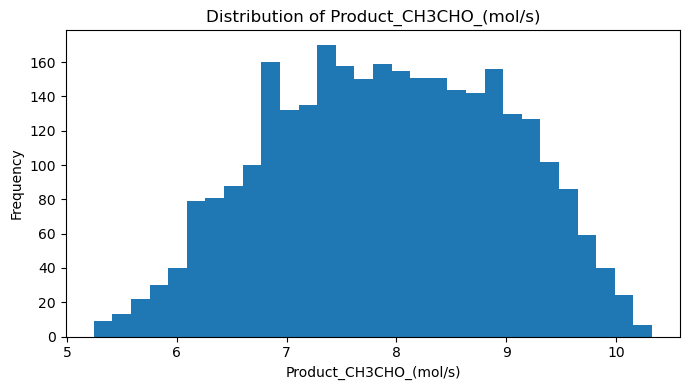

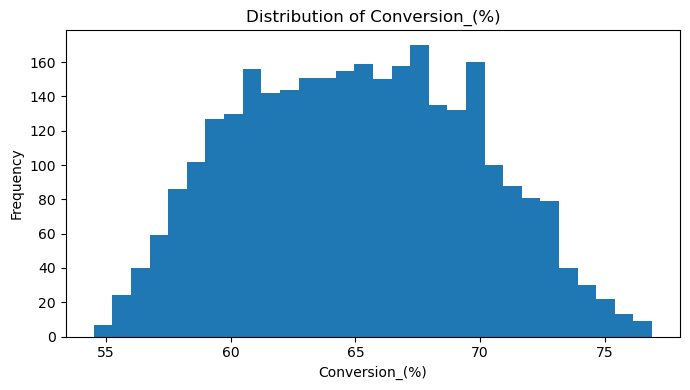

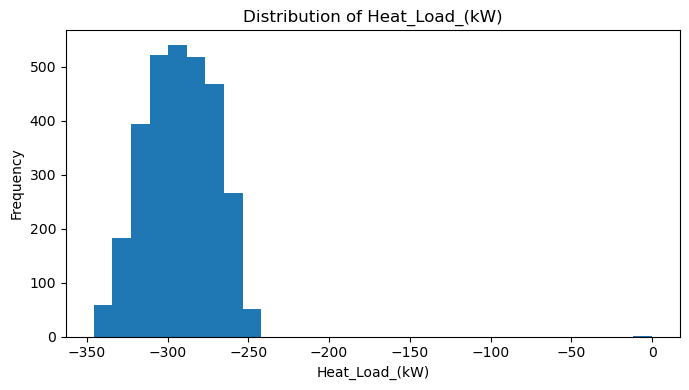

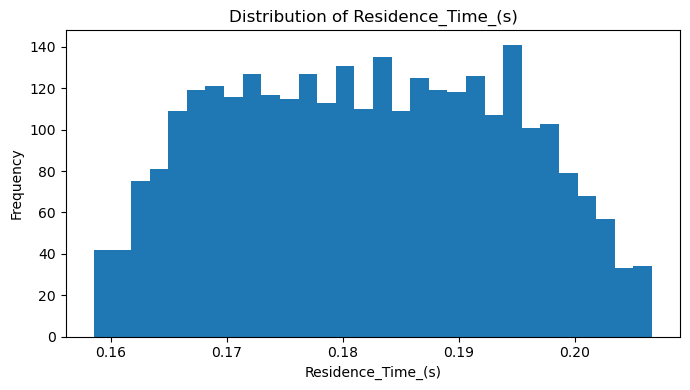

In [13]:

for col in df_num.drop(columns=op_col).columns:
    plt.figure(figsize=(7, 4))
    
    plt.hist(df_num[col], bins=30)
    
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title("Distribution of " + col)
    
    plt.tight_layout()
    plt.show()

In [36]:
correlation = df_num.corr()
correlation

,Temperature_(K),Pressure_(Pa),Volume_(m3),Feed_CH3CHO_(mol/s),Product_CH3CHO_(mol/s),Conversion_(%),Heat_Load_(kW),Residence_Time_(s)
Temperature_(K),1.000000,-0.002655,-0.002033,NaN,-0.235218,0.235218,-0.236658,-0.014824
Pressure_(Pa),-0.002655,1.000000,-0.002094,NaN,-0.386830,0.386830,-0.378062,0.281899
Volume_(m3),-0.002033,-0.002094,1.000000,NaN,-0.887560,0.887560,-0.861292,0.958607
Feed_CH3CHO_(mol/s),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_CH3CHO_(mol/s),-0.235218,-0.386830,-0.887560,NaN,1.000000,-1.000000,0.974798,-0.958719
Conversion_(%),0.235218,0.386830,0.887560,NaN,-1.000000,1.000000,-0.974798,0.958719
Heat_Load_(kW),-0.236658,-0.378062,-0.861292,NaN,0.974798,-0.974798,1.000000,-0.930987
Residence_Time_(s),-0.014824,0.281899,0.958607,NaN,-0.958719,0.958719,-0.930987,1.000000


In [37]:
conversion_corr = df_num.corr()["Conversion_(%)"].sort_values(ascending=False)
conversion_corr=conversion_corr.drop(['Feed_CH3CHO_(mol/s)','Conversion_(%)'])
conversion_corr

Residence_Time_(s)        0.958719
Volume_(m3)               0.887560
Pressure_(Pa)             0.386830
Temperature_(K)           0.235218
Heat_Load_(kW)           -0.974798
Product_CH3CHO_(mol/s)   -1.000000
Name: Conversion_(%), dtype: float64

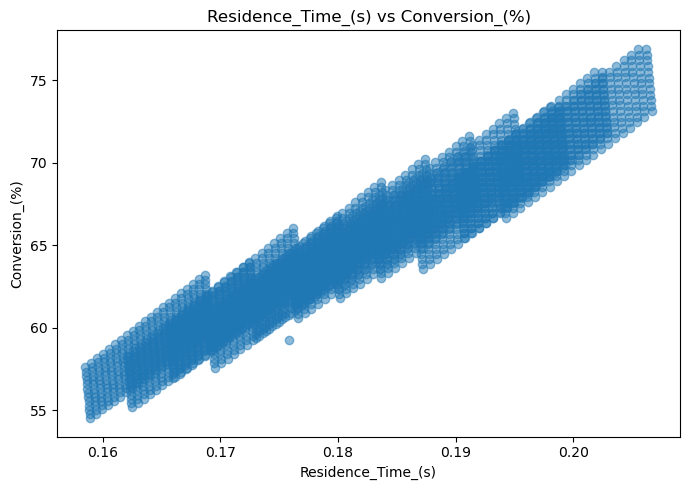

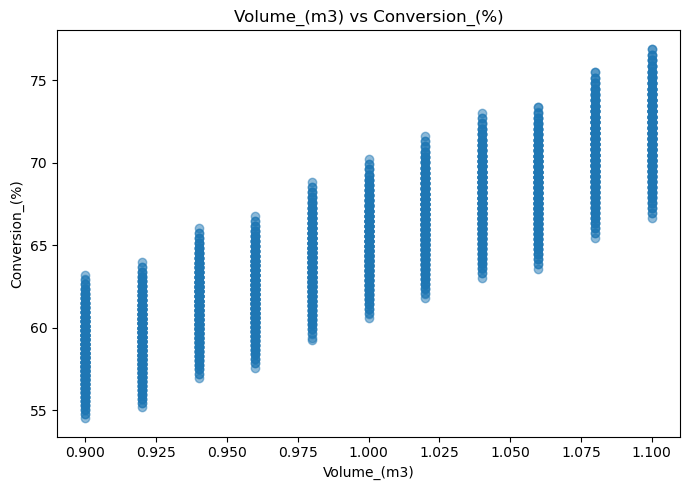

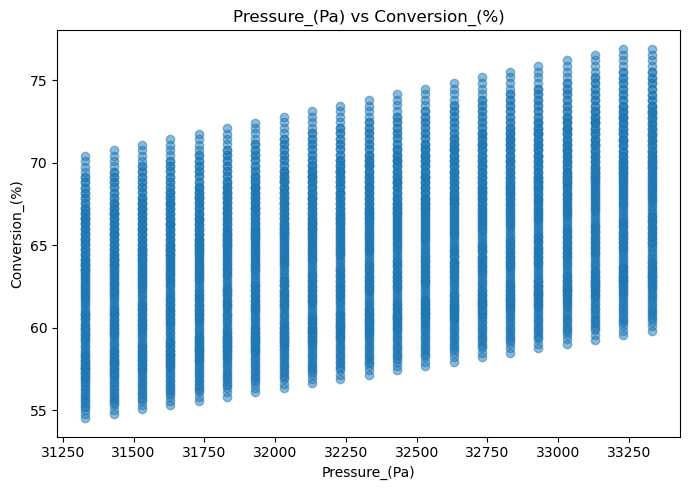

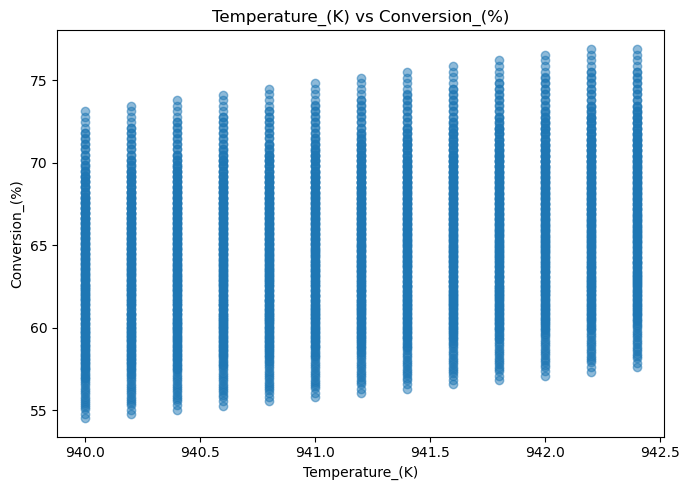

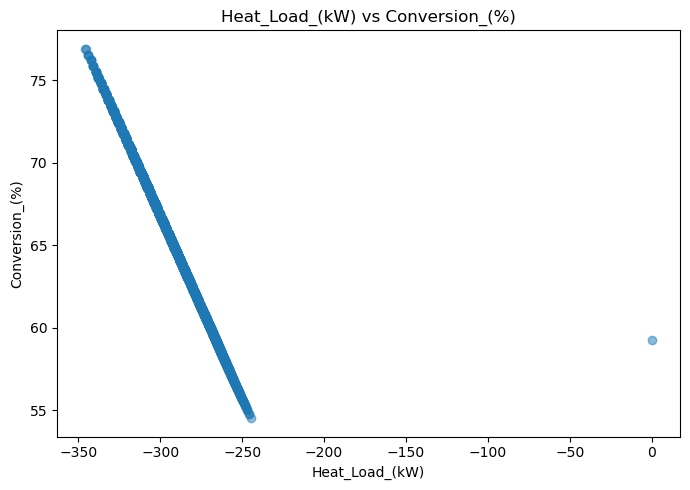

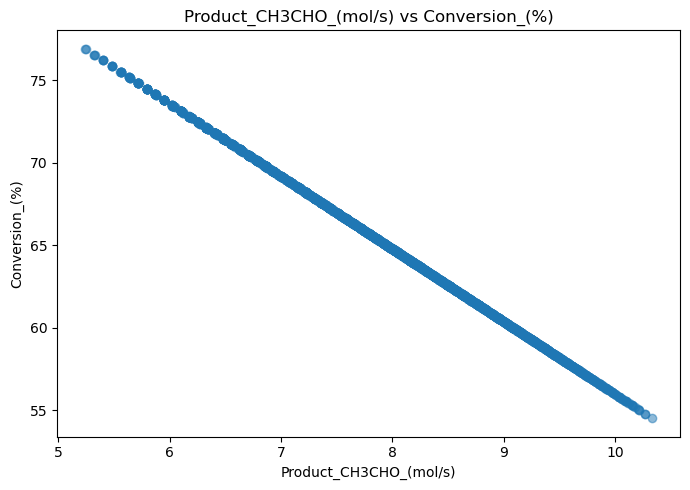

In [16]:
input_columns = [
    "Residence_Time_(s)",
    "Volume_(m3)",
    "Pressure_(Pa)",
    "Temperature_(K)",
    "Heat_Load_(kW)",        
    "Product_CH3CHO_(mol/s)"  
]

for col in input_columns:
    
    plt.figure(figsize=(7, 5))
    
    plt.scatter(df_num[col],df_num["Conversion_(%)"],alpha=0.5)
    
    plt.xlabel(col)
    plt.ylabel("Conversion_(%)")
    plt.title( col + " vs Conversion_(%)")
    
    plt.tight_layout()
    plt.show()

In [38]:
# Define ML features and target

features = [
    "Residence_Time_(s)",
    "Volume_(m3)",
    "Pressure_(Pa)",
    "Temperature_(K)",
    "Heat_Load_(kW)",        
]
target = "Conversion_(%)"

X = df_num[features].copy()
y = df_num[target].copy()

print("Input features:")
print(features)

print("\nTarget:",target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:
['Residence_Time_(s)', 'Volume_(m3)', 'Pressure_(Pa)', 'Temperature_(K)', 'Heat_Load_(kW)']

Target: Conversion_(%)

X shape: (3000, 5)
y shape: (3000,)


In [39]:
# Check feature scales

scale_check = X.describe().T[ ["min", "max", "mean", "std"] ]

print(scale_check)

                             min           max          mean         std
Residence_Time_(s)      0.158546      0.206676      0.181997    0.011999
Volume_(m3)             0.900000      1.100000      0.999920    0.063235
Pressure_(Pa)       31330.000000  33330.000000  32329.000000  605.106920
Temperature_(K)       940.000000    942.400000    941.198800    0.747867
Heat_Load_(kW)       -345.689625      0.000000   -292.437314   21.774821


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining percentage:", X_train.shape[0] / len(X) * 100)
print("Testing percentage :", X_test.shape[0] / len(X) * 100)

Training samples: 2400
Testing samples : 600

Training percentage: 80.0
Testing percentage : 20.0


In [41]:


scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

print("Original training data:")
print(X_train.head())

print("\nScaled training data:")
print(X_train_scaled[:5])

Original training data:
      Residence_Time_(s)  Volume_(m3)  Pressure_(Pa)  Temperature_(K)  \
642             0.181842         0.98          32930            940.4   
700             0.183559         1.04          31330            940.6   
226             0.191645         1.02          33330            940.0   
1697            0.173078         0.96          32030            941.4   
1010            0.194837         1.08          32030            940.8   

      Heat_Load_(kW)  
642      -289.992957  
700      -286.932193  
226      -304.493022  
1697     -276.168932  
1010     -309.420137  

Scaled training data:
[[-0.01172031 -0.3185531   1.00892588 -1.09045269  0.11252343]
 [ 0.13193699  0.62959998 -1.63635296 -0.82211613  0.25316314]
 [ 0.80832698  0.31354896  1.67024559 -1.6271258  -0.55374304]
 [-0.74486474 -0.63460412 -0.47904346  0.2512301   0.74772643]
 [ 1.07536527  1.26170204 -0.47904346 -0.55377957 -0.78014007]]


In [42]:
scaled_check = pd.DataFrame(
    X_train_scaled,
    columns=features
)

print(scaled_check.describe().T[["mean", "std", "min", "max"]])

                            mean       std       min        max
Residence_Time_(s) -1.415164e-15  1.000208 -1.960547   2.065728
Volume_(m3)        -2.084259e-15  1.000208 -1.582757   1.577753
Pressure_(Pa)       1.184238e-17  1.000208 -1.636353   1.670246
Temperature_(K)    -1.389081e-13  1.000208 -1.627126   1.592913
Heat_Load_(kW)      7.815970e-16  1.000208 -2.444502  13.437470


In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

In [44]:

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [45]:
results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

    trained_models[name] = model

results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")
print(results_df.round(4))

Training Linear Regression...
Training XGBoost...
Training KNN...

MODEL COMPARISON
               Model  Train R2  Test R2  Train MAE  Test MAE  Train RMSE  \
0  Linear Regression    0.9964   0.9970     0.2305    0.2250      0.2781   
1            XGBoost    1.0000   0.9998     0.0121    0.0275      0.0165   
2                KNN    0.9994   0.9993     0.0613    0.0848      0.1156   

   Test RMSE  
0     0.2635  
1     0.0619  
2     0.1307  


In [47]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline


cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ])
}

In [48]:
cv_results = []

for name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "R2": "r2",
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV R2 Mean": scores["test_R2"].mean(),
        "CV R2 Std": scores["test_R2"].std(),
        "CV MAE Mean": -scores["test_MAE"].mean(),
        "CV RMSE Mean": -scores["test_RMSE"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df.round(5))

,Model,CV R2 Mean,CV R2 Std,CV MAE Mean,CV RMSE Mean
0,Linear Regression,0.92792,0.13720,0.21132,0.75949
1,XGBoost,0.99960,0.00056,0.02604,0.07626
2,KNN,0.99846,0.00059,0.11856,0.17955


In [49]:
predictions = {}

for name, model in cv_models.items():
    model.fit(X_train_scaled, y_train)
    predictions[name] = model.predict(X_test_scaled)

print("Predictions generated for all 3 models.")

Predictions generated for all 3 models.


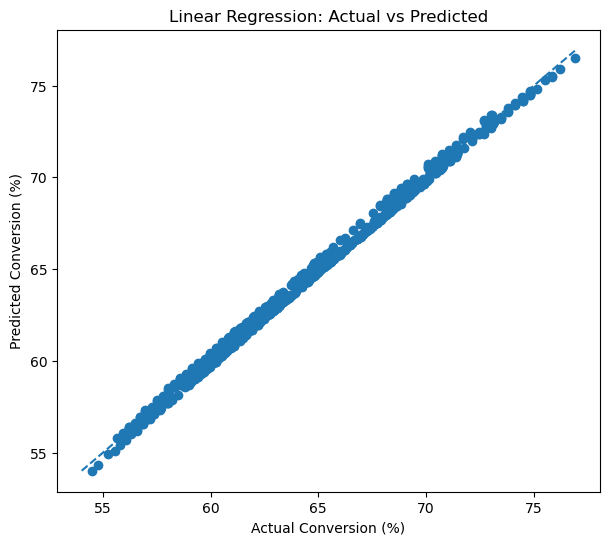

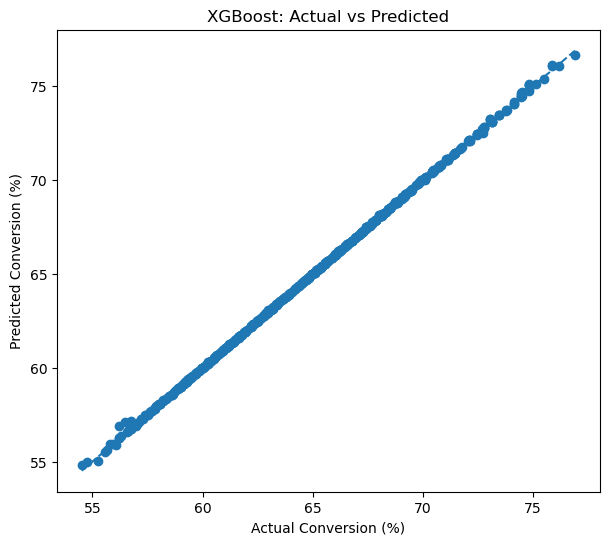

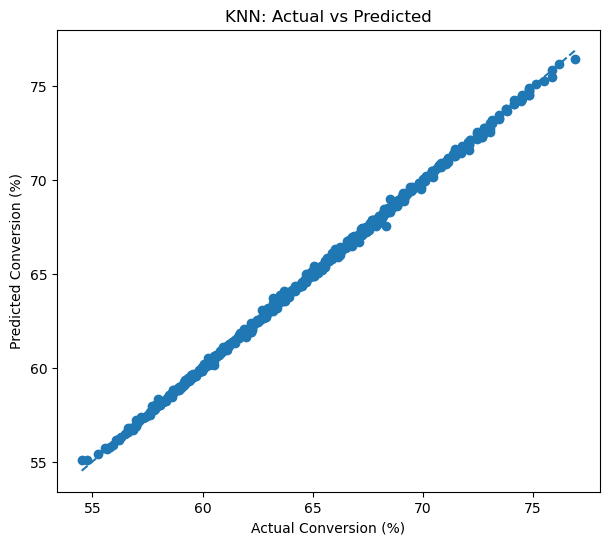

In [50]:
import matplotlib.pyplot as plt

for name, y_pred in predictions.items():

    plt.figure(figsize=(7, 6))

    plt.scatter(y_test, y_pred)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    plt.xlabel("Actual Conversion (%)")
    plt.ylabel("Predicted Conversion (%)")
    plt.title(f"{name}: Actual vs Predicted")

    plt.show()

In [51]:
residuals = {}

for name, y_pred in predictions.items():
    residuals[name] = y_test.values - y_pred

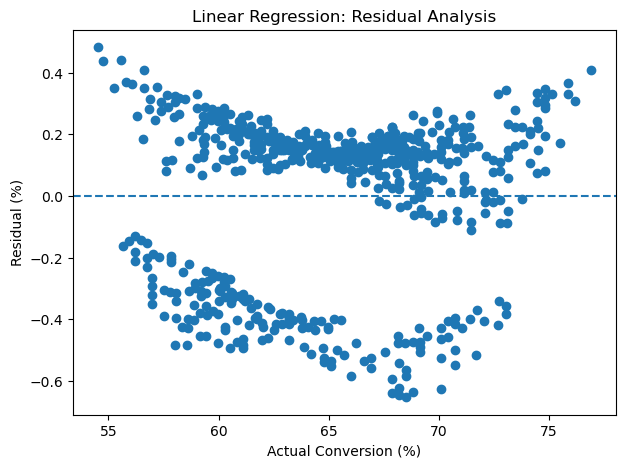

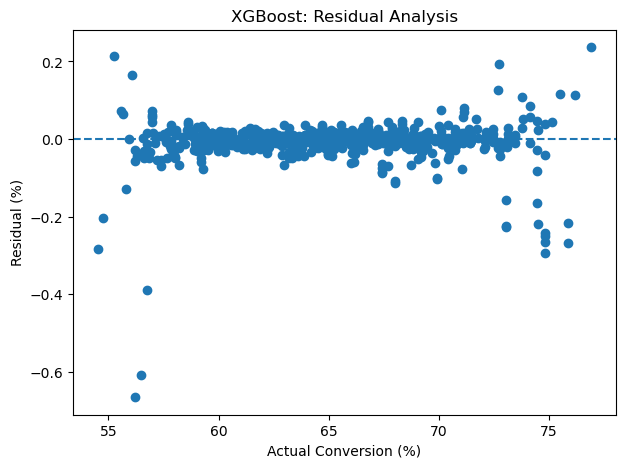

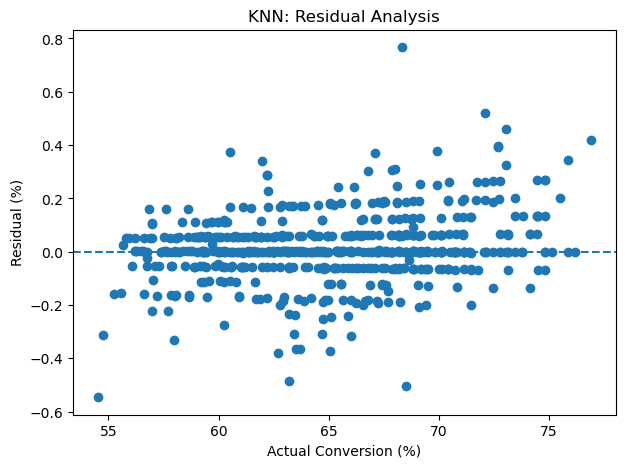

In [52]:
for name, residual in residuals.items():

    plt.figure(figsize=(7, 5))

    plt.scatter(y_test, residual)

    plt.axhline(
        y=0,
        linestyle="--"
    )

    plt.xlabel("Actual Conversion (%)")
    plt.ylabel("Residual (%)")
    plt.title(f"{name}: Residual Analysis")

    plt.show()

In [53]:
# ============================================================
# LINEAR REGRESSION COEFFICIENT ANALYSIS
# ============================================================

# Get the Linear Regression pipeline
linear_pipeline = cv_models["Linear Regression"]

# Fit the pipeline on the training data
linear_pipeline.fit(X_train, y_train)

# Extract scaler and Linear Regression model
linear_scaler = linear_pipeline.named_steps["scaler"]
linear_model = linear_pipeline.named_steps["model"]

# ------------------------------------------------------------
# Standardized coefficients
# ------------------------------------------------------------

standardized_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

standardized_coefficients["Absolute_Importance"] = (
    standardized_coefficients["Coefficient"].abs()
)

standardized_coefficients = standardized_coefficients.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("STANDARDIZED FEATURE COEFFICIENTS")
display(standardized_coefficients.round(6))

# ------------------------------------------------------------
# Original-unit coefficients
# ------------------------------------------------------------

original_coefficients = linear_model.coef_ / linear_scaler.scale_

original_coefficients_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": original_coefficients
})

original_coefficients_df["Absolute_Importance"] = (
    original_coefficients_df["Coefficient"].abs()
)

original_coefficients_df = original_coefficients_df.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("\nORIGINAL-UNIT FEATURE COEFFICIENTS")
display(original_coefficients_df.round(6))

# ------------------------------------------------------------
# Intercept
# ------------------------------------------------------------

print(
    f"\nLinear Regression Intercept: "
    f"{linear_model.intercept_:.6f}"
)

STANDARDIZED FEATURE COEFFICIENTS


,Feature,Coefficient,Absolute_Importance
0,Residence_Time_(s),5.708325,5.708325
1,Volume_(m3),-1.651646,1.651646
3,Temperature_(K),1.090218,1.090218
4,Heat_Load_(kW),-0.377205,0.377205
2,Pressure_(Pa),0.056235,0.056235



ORIGINAL-UNIT FEATURE COEFFICIENTS


,Feature,Coefficient,Absolute_Importance
0,Residence_Time_(s),477.524135,477.524135
1,Volume_(m3),-26.100225,26.100225
3,Temperature_(K),1.462727,1.462727
4,Heat_Load_(kW),-0.017332,0.017332
2,Pressure_(Pa),0.000093,0.000093



Linear Regression Intercept: 65.101702


In [54]:
optimization_ranges = pd.DataFrame({
    "Minimum": X.min(),
    "Maximum": X.max()
})

display(optimization_ranges)

,Minimum,Maximum
Residence_Time_(s),0.158546,0.206676
Volume_(m3),0.900000,1.100000
Pressure_(Pa),31330.000000,33330.000000
Temperature_(K),940.000000,942.400000
Heat_Load_(kW),-345.689625,0.000000


In [67]:
# Generate candidate operating conditions

import numpy as np
import pandas as pd

n_candidates = 10000

rng = np.random.default_rng(42)

candidates = pd.DataFrame({
    "Residence_Time_(s)": rng.uniform(0.158546, 0.206676, n_candidates),
    "Volume_(m3)": rng.uniform(0.90, 1.10, n_candidates),
    "Pressure_(Pa)": rng.uniform(31330.0, 33330.0, n_candidates),
    "Temperature_(K)": rng.uniform(940.0, 942.4, n_candidates),
    "Heat_Load_(kW)": rng.uniform(-345.689625,0, n_candidates),
})

display(candidates.head())

,Residence_Time_(s),Volume_(m3),Pressure_(Pa),Temperature_(K),Heat_Load_(kW)
0,0.195797,1.044146,32811.545509,940.833101,-244.948839
1,0.179669,1.042248,33321.612931,941.010439,-303.917705
2,0.199870,0.940539,31411.954618,942.363279,-308.571933
3,0.192110,0.907331,31819.838869,940.202066,-342.459677
4,0.163079,0.960760,32525.481497,940.267963,-7.481985


In [68]:
# Predict conversion

candidates_scaled = scaler.fit_transform(candidates)

candidates["Predicted_Conversion_(%)"] = (
    trained_models["XGBoost"].predict(candidates_scaled)
)

display(
    candidates.sort_values(
        "Predicted_Conversion_(%)",
        ascending=False
    ).head(10)
)

,Residence_Time_(s),Volume_(m3),Pressure_(Pa),Temperature_(K),Heat_Load_(kW),Predicted_Conversion_(%)
8771,0.205160,0.986492,33149.901951,942.395198,-345.627873,73.578270
8790,0.201159,0.998134,32954.813260,941.331361,-345.340708,73.478821
3923,0.202967,1.099174,32169.004688,941.441543,-345.190792,73.449799
9963,0.205544,1.091159,31457.455271,941.234446,-345.552121,73.447662
7752,0.201999,1.089237,31550.341018,940.615702,-345.609767,73.446678
9040,0.163885,1.012314,33278.575356,941.065152,-345.108796,73.444618
5424,0.203426,1.001770,31624.455836,940.811884,-345.519756,73.442299
7877,0.195954,1.085429,33115.262773,940.763881,-345.553976,73.439384
3247,0.197142,0.945769,33062.703567,942.220337,-345.258157,73.438225
8901,0.201934,0.950340,32478.014130,940.978954,-345.444588,73.433693


In [69]:
target_conversion = 75.0

# Allow a small tolerance around the target
tolerance = 0.5

feasible_candidates = candidates[
    candidates["Predicted_Conversion_(%)"] >= target_conversion
].copy()

print("Target conversion:", target_conversion, "%")
print("Feasible candidates:", len(feasible_candidates))

display(
    feasible_candidates.sort_values(
        "Predicted_Conversion_(%)",
        ascending=False
    ).head(10)
)

Target conversion: 75.0 %
Feasible candidates: 0


,Residence_Time_(s),Volume_(m3),Pressure_(Pa),Temperature_(K),Heat_Load_(kW),Predicted_Conversion_(%)


In [63]:
print("Maximum predicted conversion:")
print(candidates["Predicted_Conversion_(%)"].max())

print("\nCandidate closest to 75%:")

candidates["Target_Error"] = (
    candidates["Predicted_Conversion_(%)"] - target_conversion
).abs()

closest_candidate = candidates.sort_values(
    "Target_Error"
).iloc[0]

display(closest_candidate.to_frame().T)

Maximum predicted conversion:
79.62149214061628

Candidate closest to 75%:


,Residence_Time_(s),Volume_(m3),Pressure_(Pa),Temperature_(K),Heat_Load_(kW),Predicted_Conversion_(%),Target_Error
6175,0.206225,1.04856,31773.742987,941.813134,-329.509277,75.000078,0.000078


In [70]:
# Show the 10 highest-conversion cases in the dataset

top_cases = df_num.sort_values(
    "Conversion_(%)",
    ascending=False
).head(10)

display(
    top_cases[
        [
            "Residence_Time_(s)",
            "Volume_(m3)",
            "Pressure_(Pa)",
            "Temperature_(K)",
            "Conversion_(%)"
        ]
    ]
)

,Residence_Time_(s),Volume_(m3),Pressure_(Pa),Temperature_(K),Conversion_(%)
2991,0.205530,1.1,33230,942.4,76.894766
2771,0.206193,1.1,33330,942.2,76.889302
2980,0.204912,1.1,33130,942.4,76.547903
2760,0.205574,1.1,33230,942.2,76.543504
2540,0.206237,1.1,33330,942.0,76.537911
2969,0.204293,1.1,33030,942.4,76.201564
2749,0.204955,1.1,33130,942.2,76.198225
2529,0.205618,1.1,33230,942.0,76.193692
2309,0.206280,1.1,33330,941.8,76.187972
2958,0.203675,1.1,32930,942.4,75.855748


In [71]:
# Optimized condition from our ML optimization

optimized_conditions = {
    "Residence_Time_(s)": closest_candidate["Residence_Time_(s)"],
    "Volume_(m3)": closest_candidate["Volume_(m3)"],
    "Pressure_(Pa)": closest_candidate["Pressure_(Pa)"],
    "Temperature_(K)": closest_candidate["Temperature_(K)"]
}

print("Optimized operating condition:")
for key, value in optimized_conditions.items():
    print(key, ":", value)

Optimized operating condition:
Residence_Time_(s) : 0.20622477034222567
Volume_(m3) : 1.0485604288945292
Pressure_(Pa) : 31773.74298684089
Temperature_(K) : 941.8131338460455


In [74]:
# ============================================================
# TARGET CONVERSION -> BEST OPERATING CONDITION
# ============================================================

target_conversion = float(
    input("Enter target conversion (%): ")
)

# Number of candidate operating conditions
n_candidates = 50000

rng = np.random.default_rng(42)

# Generate candidates within the ranges used in our optimization
candidates = pd.DataFrame({
    "Residence_Time_(s)": rng.uniform(
        X["Residence_Time_(s)"].min(),
        X["Residence_Time_(s)"].max(),
        n_candidates
    ),

    "Volume_(m3)": rng.uniform(
        X["Volume_(m3)"].min(),
        X["Volume_(m3)"].max(),
        n_candidates
    ),

    "Pressure_(Pa)": rng.uniform(
        X["Pressure_(Pa)"].min(),
        X["Pressure_(Pa)"].max(),
        n_candidates
    ),

    "Temperature_(K)": rng.uniform(
        X["Temperature_(K)"].min(),
        X["Temperature_(K)"].max(),
        n_candidates
    ),

    "Heat_Load_(kW)": rng.uniform(
        X["Heat_Load_(kW)"].min(),
        X["Heat_Load_(kW)"].max(),
        n_candidates
    )
})

# ------------------------------------------------------------
# Use the EXISTING training scaler
# ------------------------------------------------------------

candidates_scaled = scaler.transform(candidates)

# Predict conversion using trained Linear Regression model
candidates["Predicted_Conversion_(%)"] = (
    trained_models["XGBoost"]
    .predict(candidates_scaled)
)

# Calculate error from requested target
candidates["Target_Error_(%)"] = (
    candidates["Predicted_Conversion_(%)"] -
    target_conversion
).abs()

# ------------------------------------------------------------
# Find candidates closest to requested conversion
# ------------------------------------------------------------

best_candidates = candidates.sort_values(
    "Target_Error_(%)"
).head(10)

best_condition = best_candidates.iloc[0]

# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("\n" + "="*60)
print("       ML-BASED OPERATING CONDITION SEARCH")
print("="*60)

print(f"\nTarget Conversion     : {target_conversion:.3f} %")
print(
    f"Predicted Conversion  : "
    f"{best_condition['Predicted_Conversion_(%)']:.3f} %"
)
print(
    f"Prediction Error      : "
    f"{best_condition['Target_Error_(%)']:.3f} %"
)

print("\nBest candidate operating condition:")
print("-"*60)

print(
    f"Residence Time : "
    f"{best_condition['Residence_Time_(s)']:.6f} s"
)

print(
    f"Volume         : "
    f"{best_condition['Volume_(m3)']:.6f} m³"
)

print(
    f"Pressure       : "
    f"{best_condition['Pressure_(Pa)']:.2f} Pa"
)

print(
    f"Temperature    : "
    f"{best_condition['Temperature_(K)']:.3f} K"
)

print(
    f"Heat Load      : "
    f"{best_condition['Heat_Load_(kW)']:.3f} kW"
)

print("\n" + "="*60)
print("Top 10 candidate conditions:")
print("="*60)

display(
    best_candidates[
        [
            "Residence_Time_(s)",
            "Volume_(m3)",
            "Pressure_(Pa)",
            "Temperature_(K)",
            "Heat_Load_(kW)",
            "Predicted_Conversion_(%)",
            "Target_Error_(%)"
        ]
    ].reset_index(drop=True)
)


       ML-BASED OPERATING CONDITION SEARCH

Target Conversion     : 70.000 %
Predicted Conversion  : 70.000 %
Prediction Error      : 0.000 %

Best candidate operating condition:
------------------------------------------------------------
Residence Time : 0.204844 s
Volume         : 0.996620 m³
Pressure       : 32867.38 Pa
Temperature    : 940.199 K
Heat Load      : -274.327 kW

Top 10 candidate conditions:


,Residence_Time_(s),Volume_(m3),Pressure_(Pa),Temperature_(K),Heat_Load_(kW),Predicted_Conversion_(%),Target_Error_(%)
0,0.204844,0.996620,32867.378686,940.199307,-274.326604,70.000000,0.000000
1,0.201657,1.053327,33160.643951,941.931243,-271.476339,69.999619,0.000381
2,0.166554,1.023982,33325.198286,942.230004,-273.201848,70.000381,0.000381
3,0.194326,0.903336,33226.559093,940.828312,-271.489824,69.998985,0.001015
4,0.198639,1.037525,33219.524623,940.001415,-273.031652,69.998840,0.001160
5,0.203480,1.031415,33101.727106,941.973145,-271.018578,70.001732,0.001732
6,0.204321,1.093011,33147.573201,940.932835,-270.950816,69.998001,0.001999
7,0.202652,1.096184,32867.028223,940.834120,-272.873481,69.997986,0.002014
8,0.191732,1.019398,33128.264466,941.919658,-272.874743,69.997559,0.002441
9,0.180108,1.042805,33286.438073,942.397854,-272.876859,69.997040,0.002960
